In [1]:
import json

with open('../data/SportU_Video_mc.json', 'r') as f:
    data = json.load(f)

print(f"Total examples: {len(data)}")
print(f"Keys: {list(data[0].keys())}")
print(f"\nFirst example:")
for key, value in data[0].items():
    print(f"  {key}: {value}")

Total examples: 10973
Keys: ['id', 'question', 'options', 'answer', 'difficulty level']

First example:
  id: soccer_267
  question: What main color jersey is the offensive team wearing?
  options: {'A': 'red & white', 'B': 'blue & red', 'C': 'black & red', 'D': 'black & blue'}
  answer: D
  difficulty level: medium


In [2]:
import os

# All questions
total_questions = len(data)

# Check how many questions have matching videos
video_dir = '../videos/Soccer/'
matched = 0
missing = 0

for item in data:
    video_path = os.path.join(video_dir, f"{item['id']}.mp4")
    if os.path.exists(video_path):
        matched += 1
    else:
        missing += 1

print(f"Total questions:        {total_questions}")
print(f"Questions with video:   {matched}")
print(f"Questions without video:{missing}")
print(f"\nWe will train on {matched} examples")

Total questions:        10973
Questions with video:   3969
Questions without video:7004

We will train on 3969 examples


Difficulty distribution:
  medium: 6051 questions
  easy: 3055 questions
  hard: 1867 questions


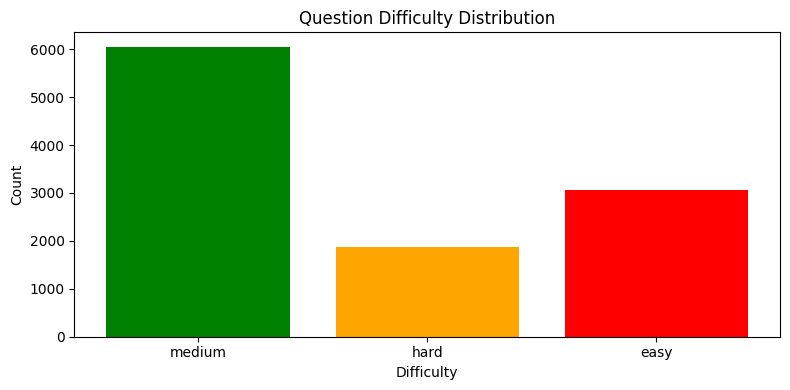


Plot saved to outputs folder!


In [3]:
from collections import Counter
import matplotlib.pyplot as plt

# Count difficulty levels
difficulties = [item['difficulty level'] for item in data]
counts = Counter(difficulties)

print("Difficulty distribution:")
for level, count in counts.most_common():
    print(f"  {level}: {count} questions")

# Plot
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=['green', 'orange', 'red'])
plt.title('Question Difficulty Distribution')
plt.xlabel('Difficulty')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/difficulty_distribution.png', dpi=150)
plt.show()
print("\nPlot saved to outputs folder!")

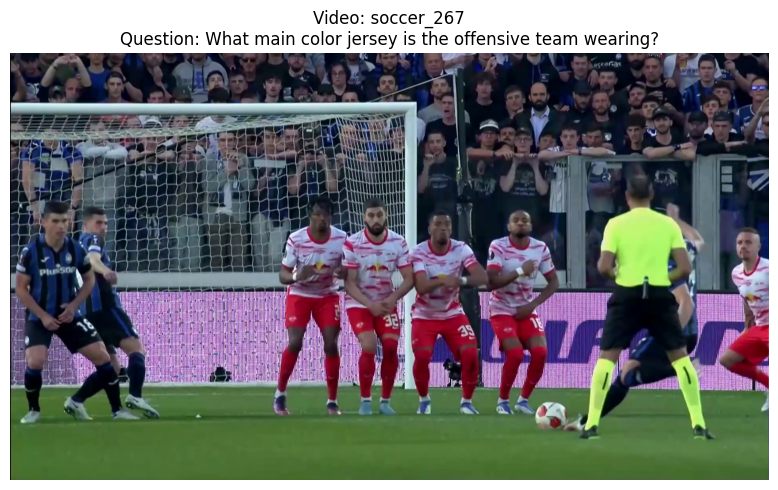

Video ID: soccer_267
Question: What main color jersey is the offensive team wearing?
Options:  {'A': 'red & white', 'B': 'blue & red', 'C': 'black & red', 'D': 'black & blue'}
Answer:   D


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load first matching video
for item in data:
    video_path = f"../videos/Soccer/{item['id']}.mp4"
    if os.path.exists(video_path):
        first_item = item
        break

# Read first frame
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(frame_rgb)
    plt.title(f"Video: {first_item['id']}\nQuestion: {first_item['question']}")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('../outputs/sample_frame.png', dpi=150)
    plt.show()
    
    print(f"Video ID: {first_item['id']}")
    print(f"Question: {first_item['question']}")
    print(f"Options:  {first_item['options']}")
    print(f"Answer:   {first_item['answer']}")